In [3]:
import pandas as pd



In [ ]:
data=pd.read_excel('data.xlsx')
data

,Temperature,Humidity,Light,CO2,HR,Occupancy
0,23.700000,26.272000,585.200000,749.200000,0.004764,1
1,23.718000,26.290000,578.400000,760.400000,0.004773,1
2,23.730000,26.230000,572.666667,769.666667,0.004765,1
3,23.722500,26.125000,493.750000,774.750000,0.004744,1
4,23.754000,26.200000,488.600000,779.000000,0.004767,1
...,...,...,...,...,...,...
2660,24.290000,25.700000,808.000000,1150.250000,0.004829,1
2661,24.330000,25.736000,809.800000,1129.200000,0.004848,1
2662,24.330000,25.700000,817.000000,1125.800000,0.004841,1
2663,24.356667,25.700000,813.000000,1123.000000,0.004849,1


In [5]:
data_1=data[data["Occupancy"]==1]
del data_1["Occupancy"]
data_1

,Temperature,Humidity,Light,CO2,HR
0,23.700000,26.272000,585.200000,749.200000,0.004764
1,23.718000,26.290000,578.400000,760.400000,0.004773
2,23.730000,26.230000,572.666667,769.666667,0.004765
3,23.722500,26.125000,493.750000,774.750000,0.004744
4,23.754000,26.200000,488.600000,779.000000,0.004767
...,...,...,...,...,...
2660,24.290000,25.700000,808.000000,1150.250000,0.004829
2661,24.330000,25.736000,809.800000,1129.200000,0.004848
2662,24.330000,25.700000,817.000000,1125.800000,0.004841
2663,24.356667,25.700000,813.000000,1123.000000,0.004849


In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split

data0 = pd.read_csv("data_0.csv")
data1 = pd.read_csv("data_1.csv")

train0, test0 = train_test_split(
data0,
test_size=0.2,
random_state=42
)

train1, test1 = train_test_split(
data1,
test_size=0.2,
random_state=42
)

train0.to_csv("data_0_train.csv", index=False)
test0.to_csv("data_0_test.csv", index=False)

train1.to_csv("data_1_train.csv", index=False)
test1.to_csv("data_1_test.csv", index=False)

In [7]:
data_1.to_csv("data_1.csv",index=False)

In [8]:
#

In [9]:
#

In [10]:
#

In [11]:
from mlforkidsnumbers import MLforKidsNumbers

project = MLforKidsNumbers(
    modelurl="https://mlforkids-newnumbers.1re3wh44gzos.eu-de.codeengine.appdomain.cloud/saved-models/auth0|6a4a595b536731872c116435-6/status"
)
# CHANGE THIS to something you want your
# machine learning model to classify
testvalue = {
    "Temperature" : 17,
    "Humidity" : 26,
    "Light" : 4567,
    "CO2" : 237,
    "HR" : 0.1246467576575,
}

response = project.classify(testvalue)
top_match = response[1]

label = top_match["class_name"]
confidence = top_match["confidence"]

# CHANGE THIS to do something different with the result
print ("result: '%s' with %d%% confidence" % (label, confidence))

 MLforKids : Checking for downloaded model... 
 MLforKids : Reusing downloaded model from saved_models\auth0_6a4a595b536731872c116435-6 
 MLforKids : Loading model... 
 MLforKids : Accessing model metadata... 
 MLforKids : Model trained at 2026-08-02T14:13:35.898811 
result: '0' with 13% confidence


In [12]:
import pandas as pd
data=pd.read_csv('data_1_test.csv')
data

,Temperature,Humidity,Light,CO2,HR
0,22.680000,30.870000,433.000000,1316.666667,0.005267
1,23.290000,28.616667,466.500000,1115.666667,0.005065
2,21.000000,25.200000,451.600000,711.000000,0.003872
3,22.500000,27.000000,624.800000,1036.250000,0.004552
4,22.937143,30.405714,456.142857,1330.000000,0.005270
...,...,...,...,...,...
190,23.100000,26.000000,655.000000,994.000000,0.004546
191,21.310000,26.830000,463.000000,927.600000,0.004204
192,24.290000,25.852000,801.400000,1140.800000,0.004858
193,21.700000,27.856667,482.000000,1076.166667,0.004472


In [13]:
p=[]
for i in range(0,195):

    testvalue = {
        "Temperature" :data['Temperature'][i] ,
        "Humidity" : data['Humidity'][i] ,
        "Light" : data['Light'][i] ,
        "CO2" : data['CO2'][i] ,
        "HR" : data['HR'][i] ,
    }

    response = project.classify(testvalue)
    top_match = response[0]

    label = int(top_match["class_name"])
    p.append(label)

In [ ]:
data['prediction']=p
data

,Temperature,Humidity,Light,CO2,HR,prediction
0,22.680000,30.870000,433.000000,1316.666667,0.005267,1
1,23.290000,28.616667,466.500000,1115.666667,0.005065,1
2,21.000000,25.200000,451.600000,711.000000,0.003872,1
3,22.500000,27.000000,624.800000,1036.250000,0.004552,1
4,22.937143,30.405714,456.142857,1330.000000,0.005270,1
...,...,...,...,...,...,...
190,23.100000,26.000000,655.000000,994.000000,0.004546,1
191,21.310000,26.830000,463.000000,927.600000,0.004204,1
192,24.290000,25.852000,801.400000,1140.800000,0.004858,1
193,21.700000,27.856667,482.000000,1076.166667,0.004472,1


In [15]:
data['truth']=1
data

,Temperature,Humidity,Light,CO2,HR,prediction,truth
0,22.680000,30.870000,433.000000,1316.666667,0.005267,1,1
1,23.290000,28.616667,466.500000,1115.666667,0.005065,1,1
2,21.000000,25.200000,451.600000,711.000000,0.003872,1,1
3,22.500000,27.000000,624.800000,1036.250000,0.004552,1,1
4,22.937143,30.405714,456.142857,1330.000000,0.005270,1,1
...,...,...,...,...,...,...,...
190,23.100000,26.000000,655.000000,994.000000,0.004546,1,1
191,21.310000,26.830000,463.000000,927.600000,0.004204,1,1
192,24.290000,25.852000,801.400000,1140.800000,0.004858,1,1
193,21.700000,27.856667,482.000000,1076.166667,0.004472,1,1


In [16]:
data.to_csv('prediction_1.csv',index=False)

In [17]:
data['Temperature'][1]

np.float64(23.29)

# test

In [18]:
import pandas as pd

In [19]:
data=pd.read_csv('test_label_1.csv')
data

FileNotFoundError: [Errno 2] No such file or directory: 'test_label_1.csv'

In [ ]:
data['truth']=1
data

,Temperature,Humidity,Light,CO2,HR,prediction,truth
0,22.680000,30.870000,433.000000,1316.666667,0.005267,0,1
1,23.290000,28.616667,466.500000,1115.666667,0.005065,0,1
2,21.000000,25.200000,451.600000,711.000000,0.003872,0,1
3,22.500000,27.000000,624.800000,1036.250000,0.004552,0,1
4,22.937143,30.405714,456.142857,1330.000000,0.005270,0,1
...,...,...,...,...,...,...,...
190,23.100000,26.000000,655.000000,994.000000,0.004546,0,1
191,21.310000,26.830000,463.000000,927.600000,0.004204,0,1
192,24.290000,25.852000,801.400000,1140.800000,0.004858,0,1
193,21.700000,27.856667,482.000000,1076.166667,0.004472,0,1


In [23]:
import pandas as pd

p_0=pd.read_csv('prediction_0.csv')

p_1=pd.read_csv('prediction_1.csv')

p=pd.concat([p_0,p_1])
p.to_excel('prediction.xlsx',index=False)

In [20]:
import pandas as pd
data=pd.read_excel('prediction.xlsx')
data

,Temperature,Humidity,Light,CO2,HR,prediction,truth
0,20.810,24.956000,0.0,541.600000,0.003789,0,0
1,21.000,25.390000,444.0,718.000000,0.003901,0,0
2,20.625,24.417500,0.0,457.500000,0.003665,0,0
3,20.890,25.200000,0.0,561.400000,0.003846,0,0
4,20.700,25.000000,0.0,496.000000,0.003770,0,0
...,...,...,...,...,...,...,...
529,23.100,26.000000,655.0,994.000000,0.004546,1,1
530,21.310,26.830000,463.0,927.600000,0.004204,1,1
531,24.290,25.852000,801.4,1140.800000,0.004858,1,1
532,21.700,27.856667,482.0,1076.166667,0.004472,1,1


In [25]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score

import matplotlib.pyplot as plt

import seaborn as sns

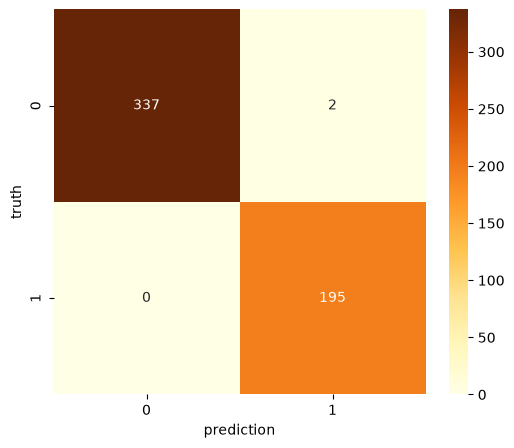

In [22]:
cm=confusion_matrix(data['truth'],data['prediction'])

plt.figure(figsize=(6, 5))

sns.heatmap(cm, annot=True, fmt='d',cmap="YlOrBr" )


plt.xlabel('prediction')

plt.ylabel('truth')
plt.show()

In [28]:
accuracy_score(data['truth'], data['prediction'])

0.9962546816479401

In [30]:
precision_score(data['truth'], data['prediction'],pos_label=0),precision_score(data['truth'], data['prediction'],pos_label=1)

(1.0, 0.9898477157360406)